cycle 1
19.930670748827964
7.019718351846888
['SiCl4' 'NO2' 'SiF4' 'O3' 'AlCl3' 'CH3NO2' 'N2O' 'C2Cl4' 'ClNO' 'NCCN']
cycle 1
dft_ele 0.20635632941442367
scf_ele 0.22653611233587317
dft_dip 0.015463491043912467
scf_dip 0.02455418336145258



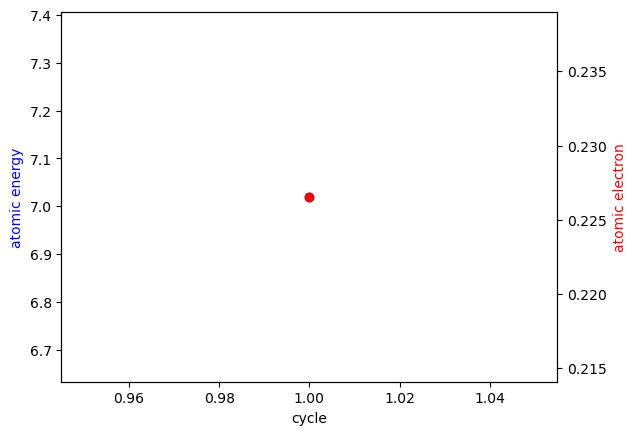

In [2]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

with open("../cc2cc/utils/g2.json") as f:
    json_data = json.load(f)

max_cycle = len(list(Path("../validate").glob("ccdft_cc-pVDZ_cycle*_g2.csv")))

data = pd.read_csv(f"../validate/ccdft_cycle{max_cycle}_g2.csv")
len_data = len(data)
data_atomic_energy_ai_save = []
data_atomic_scf_ele_save = []

for i_cycle in range(max_cycle):
    data = pd.read_csv(f"../validate/ccdft_cycle{i_cycle+1}_g2.csv")

    data = data[:len_data]

    if "_cc" in data["name"][0]:
        data["name"] = data["name"].str.split("_cc").str[0]
    elif "_Def" in data["name"][0]:
        data["name"] = data["name"].str.split("_Def").str[0]
    data_atomic_energy_dft = []
    data_atomic_energy_ai = []
    data_atomic_dft_ele = []
    data_atomic_scf_ele = []
    data_atomic_dft_dip = []
    data_atomic_scf_dip = []

    for i_name in data["name"]:
        systems_list = json_data["reaction-atomic-energy"][i_name]["systems"]
        stoichiometry_list = json_data["reaction-atomic-energy"][i_name][
            "stoichiometry"
        ]

        atomic_energy_dft = 0
        atomic_energy_ai = 0
        for i in range(len(systems_list)):
            atomic_energy_dft += data[data["name"] == systems_list[i]][
                "error_dft_ene"
            ].values[0] * int(stoichiometry_list[i])
            atomic_energy_ai += data[data["name"] == systems_list[i]][
                "error_scf_ene"
            ].values[0] * int(stoichiometry_list[i])
        data_atomic_energy_dft.append(atomic_energy_dft)
        data_atomic_energy_ai.append(atomic_energy_ai)

        data_atomic_dft_ele.append(
            data.loc[data["name"] == i_name, "error_dft_ele"].values[0]
        )
        data_atomic_scf_ele.append(
            data.loc[data["name"] == i_name, "error_scf_ele"].values[0]
        )
        data_atomic_dft_dip.append(
            data.loc[data["name"] == i_name, "error_dft_dip"].values[0]
        )
        data_atomic_scf_dip.append(
            data.loc[data["name"] == i_name, "error_scf_dip"].values[0]
        )

    print(f"cycle {i_cycle+1}")
    print(np.mean(np.abs(data_atomic_energy_dft)))
    print(np.mean(np.abs(data_atomic_energy_ai)))
    sorted_indices = np.argsort(np.abs(data_atomic_energy_ai))[::-1][:10]
    sorted_data_atomic_energy_ai = np.array(data["name"])[sorted_indices]
    print(sorted_data_atomic_energy_ai)

    print(f"cycle {i_cycle+1}")
    print("dft_ele", np.mean(np.abs(data_atomic_dft_ele)))
    print("scf_ele", np.mean(np.abs(data_atomic_scf_ele)))
    print("dft_dip", np.mean(np.abs(data_atomic_dft_dip)))
    print("scf_dip", np.mean(np.abs(data_atomic_scf_dip)))

    data_atomic_energy_ai_save.append(np.mean(np.abs(data_atomic_energy_ai)))
    data_atomic_scf_ele_save.append(np.mean(np.abs(data_atomic_scf_ele)))
    print()

# matplotlib in dual axis, left is atomic energy, right is atomic dipole
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.set_xlabel("cycle")
ax1.set_ylabel("atomic energy", color="b")
ax2.set_ylabel("atomic electron", color="r")
ax1.plot(
    range(1, max_cycle + 1),
    data_atomic_energy_ai_save,
    ls="-",
    marker="o",
    c="b",
)
ax2.plot(
    range(1, max_cycle + 1),
    data_atomic_scf_ele_save,
    ls="-",
    marker="o",
    c="r",
)

In [12]:
data_atomic_energy_ai

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 -3.5030942264716236,
 -3.004579065777377,
 -5.124791957763462,
 -8.83563541225415,
 -2.187152635271628,
 -10.659243748694582,
 -11.897500506586296]

In [13]:
data_atomic_energy_dft

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 -14.836886124209895,
 -18.625503441507192,
 -26.73012139879606,
 -19.620201214733367,
 -9.91580517694996,
 -29.51440446597997,
 -39.2074173029273]